In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl



plt.style.use('seaborn-v0_8-whitegrid')
#plt.style.use('Solarize_Light2')

In [ ]:
# read in staff ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\table-4.csv"

df = pd.read_csv(path, header=22)

# Filter for TNR and R contracts
filtered_df = df[df['Academic employment function'].str.contains('Research only|Both teaching and research', case=False, na=False) &
                 df['Sex'].str.contains('All', case=False, na=False) &
                 df['Mode of employment'].str.contains('All', case=False, na=False) &
                 df['Country of HE provider'].str.contains('All', case=False, na=False) &
                 df['Terms of employment'].str.contains('Fixed-term|Open-ended/Permanent', case=False, na=False) &
                 df['Nationality marker'].str.contains('All', case=False, na=False)].copy()


# Pivot the DataFrame to create multi index by characteristics of interest
df_pivot = filtered_df.pivot(index=['Academic year','Terms of employment','Academic employment function'], columns=['Ethnicity'], values='Number')


# Combine ethnicity stats to match UKRI breakdown catagories and create new dataframe copy
df_pivot['Asian'] = df_pivot.filter(like='Asian',axis=1).sum(axis=1)
df_pivot['Black'] = df_pivot.filter(like='Black',axis=1).sum(axis=1)
df_employment_terms = df_pivot[['White','Asian','Black','Mixed or multiple ethnic background','Not known','Any other ethnic background','Total academic staff']].copy()

df_employment_terms = df_employment_terms.groupby(level=[0,1]).sum().copy()

#convert into percentages of total employed staff
df_normalised_employ_terms = df_employment_terms.div(df_employment_terms['Total academic staff'],axis=0) * 100


In [4]:
df_hesa_benchmark = df_normalised_employ_terms.loc[['2014/15','2021/22']].copy()
df_hesa_benchmark

Ethnicity                               White      Asian     Black  \
Academic year Terms of employment                                    
2014/15       Fixed-term            70.746413  12.540697  1.447003   
              Open-ended/Permanent  81.736353   7.283198  1.345335   
2021/22       Fixed-term            62.038621  16.927402  2.639941   
              Open-ended/Permanent  76.366851  10.232115  2.148880   

Ethnicity                           Mixed or multiple ethnic background  \
Academic year Terms of employment                                         
2014/15       Fixed-term                                       2.061980   
              Open-ended/Permanent                             1.384050   
2021/22       Fixed-term                                       3.495478   
              Open-ended/Permanent                             2.280352   

Ethnicity                           Not known  Any other ethnic background  \
Academic year Terms of employment                                            
2014/15       Fixed-term            11.093693                     2.110213   
              Open-ended/Permanent   6.625048                     1.630856   
2021/22       Fixed-term            11.403080                     3.507700   
              Open-ended/Permanent   6.686916                     2.275818   

Ethnicity                           Total academic staff  
Academic year Terms of employment                         
2014/15       Fixed-term                           100.0  
              Open-ended/Permanent                 100.0  
2021/22       Fixed-term                           100.0  
              Open-ended/Permanent                 100.0

In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\ukri_fellows_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1]

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'Fellowship'])

df_ukri_benchmark = ukri_applications.loc[['2014','2021']].fillna(0).copy()
df_ukri_benchmark

Asian  Black  Mixed  Not Disclosed  Other  Unknown  \
Academic Years Fellowship                                                       
2014           applicants   10.0    1.0    3.0            7.0    0.0      1.0   
               awardees      9.0    0.0    3.0            8.0    0.0      0.0   
2021           applicants   15.0    1.0    4.0            5.0    1.0      0.0   
               awardees     12.0    2.0    4.0            5.0    0.0      1.0   

                           White  
Academic Years Fellowship         
2014           applicants   78.0  
               awardees     77.0  
2021           applicants   73.0  
               awardees     75.0

In [ ]:
# read in UKRI fellows ethnicity data from csv file
path = "C:\\Users\\ct832900\\Desktop\\EDI Research\\Fellowship_data_analysis\\Data\\PI_data.csv"
df = pd.read_csv(path, header=[0,1])

council_keys = np.unique(df['Council'])

# isolating council and ethnicity data
fixed_attributes = df[['Characteristic','Council']]
fixed_attributes.columns = fixed_attributes.columns.droplevel(1)

# Select only 'Applicants' and 'Awardees' columns and stack
df_applicants = df.loc[:, (slice(None), ['Applicants (%)'])].stack(level=1, future_stack=True)
df_awardees = df.loc[:, (slice(None), ['Awardees (%) '])].stack(level=1, future_stack=True)

df_applicants = df_applicants.droplevel(1)
df_awardees = df_awardees.droplevel(1)

df_merged_applicants = df_applicants.merge(fixed_attributes, left_index=True, right_index=True)
df_merged_awardees = df_awardees.merge(fixed_attributes, left_index=True, right_index=True)

df_final = df_merged_applicants.set_index(['Council', 'Characteristic'])

council_label = council_keys[-1]

df_test = df_final.loc[council_label]
df_long = df_test.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed = df_long.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed.columns.name = None  # Remove the columns' name for cleaner output

df_final_awardees = df_merged_awardees.set_index(['Council', 'Characteristic'])

df_test_awardees = df_final_awardees.loc[council_label]
df_long_awardees = df_test_awardees.reset_index().melt(id_vars="Characteristic", var_name="Academic Year", value_name="Percentage")
df_transformed_awardees = df_long_awardees.pivot(index="Academic Year", columns="Characteristic", values="Percentage")
df_transformed_awardees.columns.name = None  # Remove the columns' name for cleaner output

# combine applications and awardees dataframes
ukri_applications = pd.concat({'applicants': df_transformed, 'awardees': df_transformed_awardees}, axis=0)

# fix indexing to make plotting easier
ukri_applications = ukri_applications.swaplevel().sort_index(level=0)
ukri_applications.index = ukri_applications.index.set_names(['Academic Years', 'PI'])

df_PI_benchmark = ukri_applications.loc[['2014','2021']].fillna(0).copy()

In [8]:
df_hesa_change = df_hesa_benchmark.loc['2021/22'][['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background']] - df_hesa_benchmark.loc['2014/15'][['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background']]
df_ukri_change = df_ukri_benchmark.loc['2021'][['Asian','Black','Mixed','Other']] - df_ukri_benchmark.loc['2014'][['Asian','Black','Mixed','Other']]
df_PI_change = df_PI_benchmark.loc['2021'][['Asian','Black','Mixed','Other']] - df_PI_benchmark.loc['2014'][['Asian','Black','Mixed','Other']]

In [9]:
df_hesa_change.sum(axis=1), df_ukri_change.sum(axis=1), df_PI_change.sum(axis=1)

(Terms of employment
 Fixed-term              8.410627
 Open-ended/Permanent    5.293728
 dtype: float64,
 Fellowship
 applicants    7.0
 awardees      6.0
 dtype: float64,
 PI
 applicants    5.0
 awardees      5.0
 dtype: float64)

In [10]:
### Custom colors
colors = [
    "#cecece",  # grey
    "#a559aa",  # purple
    "#59a89c",  # teal
    "#f0c571",  # gold
    "#e02b35",  # red
    "#082a54",  # dark blue
]


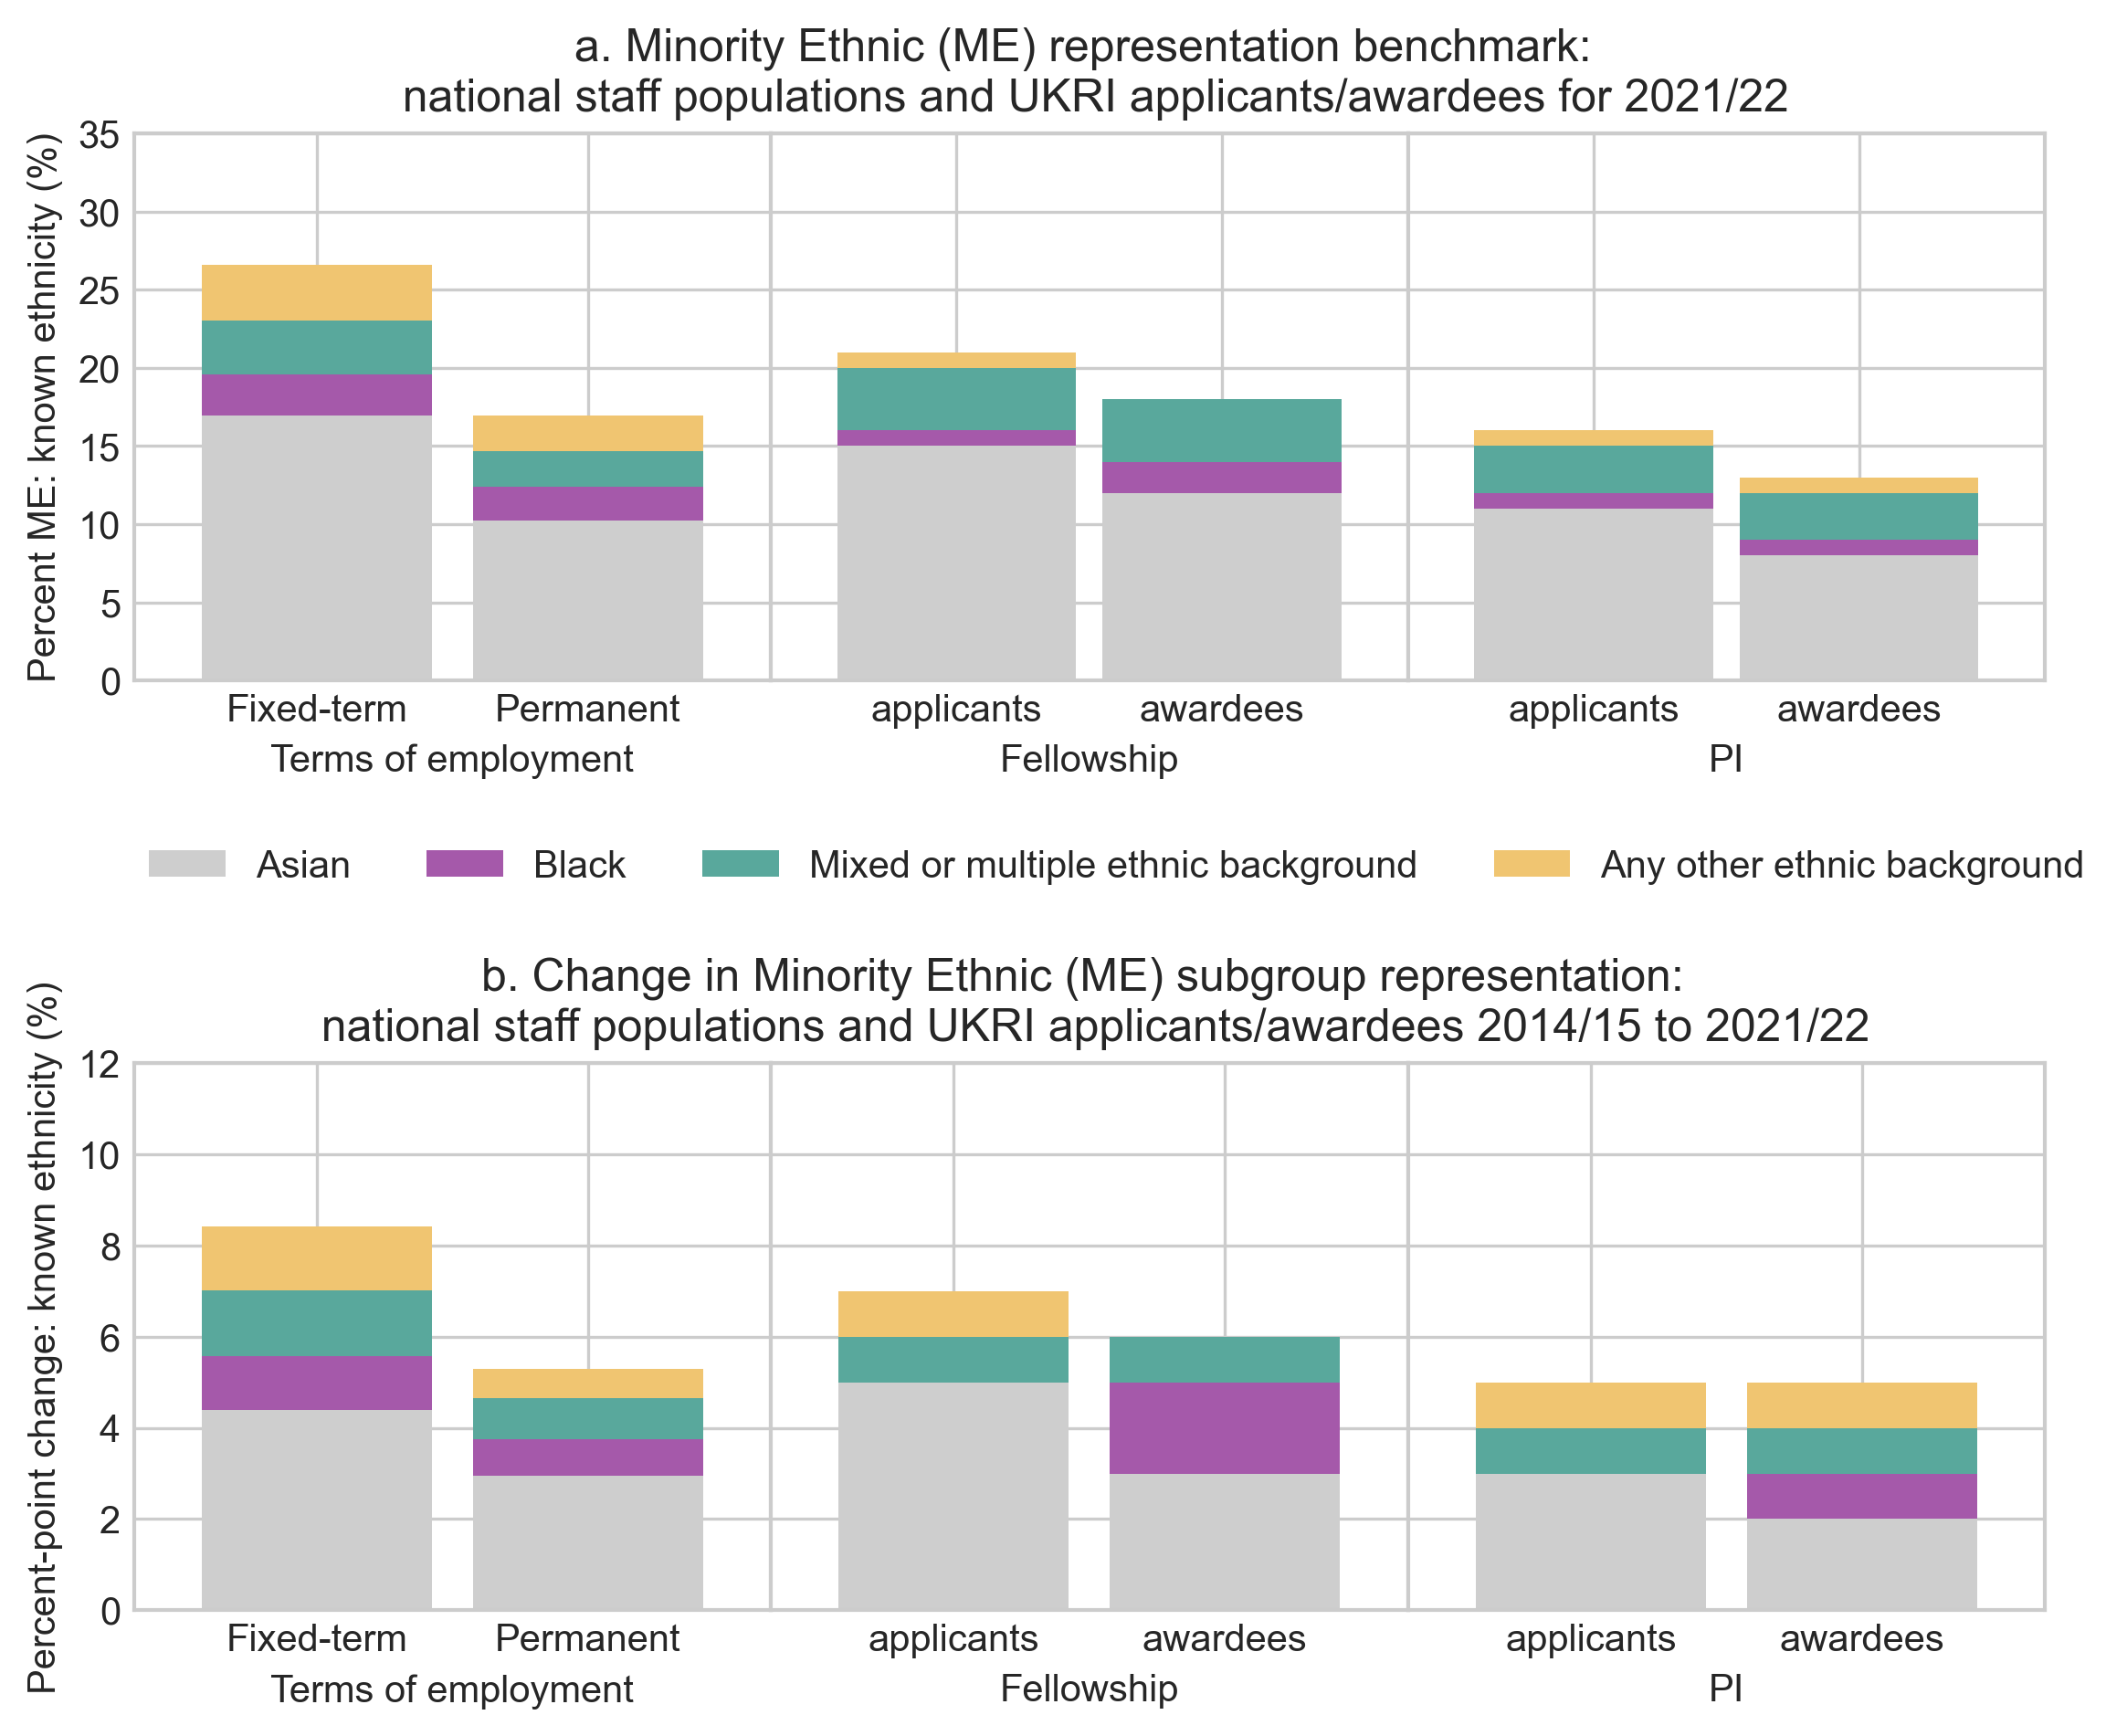

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9,7), dpi=300)

df_hesa_benchmark.loc['2021/22'][['Asian','Black','Mixed or multiple ethnic background','Any other ethnic background']].plot(kind='bar', stacked='True', legend=False, ax=axes[0,0], width=0.85, color=colors)
df_ukri_benchmark.loc['2021'][['Asian','Black','Mixed','Other']].plot(kind='bar', stacked='True', legend=False, ax=axes[0,1], width=0.9, color=colors)#
df_PI_benchmark.loc['2021'][['Asian','Black','Mixed','Other']].plot(kind='bar', stacked='True', legend=False, ax=axes[0,2], width=0.9, color=colors)


df_hesa_change.plot(kind='bar', stacked='True', legend=False, ax=axes[1,0], width=0.85, color=colors)
df_ukri_change.plot(kind='bar', stacked='True', legend=False, ax=axes[1,1], width=0.85, color=colors)
df_PI_change.plot(kind='bar', stacked='True', legend=False, ax=axes[1,2], width=0.85, color=colors)


axes[0,1].set_title('a. Minority Ethnic (ME) representation benchmark: \n national staff populations and UKRI applicants/awardees for 2021/22')
axes[1,1].set_title('b. Change in Minority Ethnic (ME) subgroup representation: \n national staff populations and UKRI applicants/awardees 2014/15 to 2021/22')
axes[0,0].set_xticklabels(['Fixed-term','Permanent'])
axes[1,0].set_xticklabels(['Fixed-term','Permanent'])

for ax in axes.flatten():
    ax.tick_params('x', labelrotation=0)

for ax in axes[0,1:]:
    ax.set_yticklabels([])

for ax in axes[1,1:]:
    ax.set_yticklabels([])

for ax in axes[0,:]:
    ax.set_ylim(0,35)
for ax in axes[1,:]:
    ax.set_ylim(0,12)

axes[0,0].legend(frameon=False, loc=(0,-0.4), ncols=4)
axes[0,0].set_ylabel('Percent ME: known ethnicity (%)')
axes[1,0].set_ylabel('Percent-point change: known ethnicity (%)')

plt.subplots_adjust(wspace=0, hspace=0.7)


fname = 'benchmark.svg'
fname_tiff = 'benchmark.tiff'

filepath = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname}"
filepath_tiff = f"C:\\Users\\ct832900\\OneDrive - University of Reading\\EDI_fellows_project\\Figures\\Draft 4 figures\\{fname_tiff}"


#plt.savefig(filepath, format = 'svg', dpi = 300,bbox_inches='tight')
#plt.savefig(filepath_tiff, format = 'tiff', dpi = 300,bbox_inches='tight')
plt.show()